# Mandatory red-team revision: Regev-style sampling, rooted bases, and a real lattice endpoint

**Status: not publication-ready.** This notebook supersedes the earlier
contribution and novelty conclusions. The hard-box chi-squared formula is a
standard Parseval identity, the (N=437) example is a root-metadata regression
test, and the old bounded-search endpoint was circular with the selector.

The revised experiment uses immutable ((b_i,a_i=b_i^2mod N)) pairs, exact
integer augmented-lattice LLL, Regev's Claim 5.1 prefix, exact (L/L_0)
classification, 24 new held-out values of (N), and three sampling models.


## 1. Frozen design and full recomputation

The complete configuration is written before any held-out result. (N), not
the 32 Monte Carlo repeats within a cell, is the generalization unit.


In [1]:
from pathlib import Path
import json, subprocess, sys
import numpy as np
import pandas as pd
import qiskit, qiskit_aer
from IPython.display import Image, display

ROOT = Path.cwd()
assert (ROOT / 'RegevImplementationAndTestingBuilding_work-3.ipynb').exists()
print('Python:', sys.version.split()[0])
print('Qiskit:', qiskit.__version__, 'Aer:', qiskit_aer.__version__)
print('External arithmetic commit audited:', 'a18f75d414485086db9b257407e0bd01f8a8f81c')


Python: 3.14.3
Qiskit: 2.5.0 Aer: 0.17.2
External arithmetic commit audited: a18f75d414485086db9b257407e0bd01f8a8f81c


In [2]:
# Recompute 24 N x 6 methods x 3 models x 32 trials, plus exact A/B laws.
subprocess.run([sys.executable, 'scripts/run_redteam.py'], check=True)
config = json.loads((ROOT / 'results/redteam/configuration.json').read_text())
config


{'candidate_root_pool': [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37],
 'development_and_excluded_inputs': {'exclusion_rules': ['exclude every input used in the original analysis or notebook diagrams',
   'exclude N=1763 used to select feasible D/R and validate code',
   'require every prime factor to exceed max candidate root 37',
   'exclude even N and prime N'],
  'pre_freeze_feasibility_only': [1763],
  'prior_primary_or_notebook': [15,
   21,
   57,
   169,
   247,
   289,
   299,
   323,
   361,
   391,
   437,
   2021,
   4199,
   7429]},
 'dimension': 3,
 'factor_blindness': {'known_factors_used_only_for_posthoc_validation': True,
  'model_C_generator_oracle_not_passed_to_reconstruction': True,
  'reconstruction_receives': ['rooted family',
   'raw samples',
   'D',
   'S',
   'T bound'],
  'selection_never_receives': ['factors',
   'group orders',
   'arbitrary square roots',
   'planted relations'],
  'selection_receives': ['N',
   'candidate roots',
   'd',
   'relation bound

## 2. Original notebook baseline

The notebook prepares uniform amplitudes on a Cartesian exponent box, computes

\[
h_A(x)=\prod_i a_i^{x_i}\bmod N,
\]

discards the oracle register, and applies one QFT per coordinate. It does not
prepare Regev's Gaussian state and contains no multidimensional lattice
reconstruction. Its displayed factor for (N=15) comes from base-generation
GCDs before samples are inspected.


In [3]:
from regev_research.core import (
    RootedBaseFamily, audit_square_base_family,
    exact_uniform_fourier_distribution, notebook_squared_prime_bases,
)

for N, d, bases, D in [(15, 2, [4, 4], 16), (21, 3, [4, 4, 16], 16)]:
    generated = notebook_squared_prime_bases(N, d)
    audit = audit_square_base_family(generated['family'], relation_bound=2)
    p, _ = exact_uniform_fourier_distribution(N, bases, D)
    top = np.argsort(p.ravel())[-3:][::-1]
    print({
        'N': N, 'pairs': generated['pairs'],
        'setup_GCD_leaks': generated['setup_factor_leaks'],
        'relation_or_collision_factors': audit['setup_factor_leaks'],
        'top_exact_probabilities': [
            (tuple(int(v) for v in np.unravel_index(i, p.shape)), float(p.ravel()[i]))
            for i in top
        ],
    })


{'N': 15, 'pairs': [{'root': 2, 'base': 4}, {'root': 7, 'base': 4}], 'setup_GCD_leaks': [(3, 3, 5), (5, 5, 3)], 'relation_or_collision_factors': [3, 5], 'top_exact_probabilities': [((0, 0), 0.5), ((8, 8), 0.5), ((4, 15), 0.0)]}
{'N': 21, 'pairs': [{'root': 2, 'base': 4}, {'root': 5, 'base': 4}, {'root': 11, 'base': 16}], 'setup_GCD_leaks': [(3, 3, 7), (7, 7, 3)], 'relation_or_collision_factors': [3, 7], 'top_exact_probabilities': [((0, 0, 0), 0.3333333730697632), ((11, 11, 5), 0.10709064598386533), ((5, 5, 11), 0.10709064598386533)]}


## 3. Roots, bases, (L), and (L_0)

The selected roots and derived circuit bases are different objects:

\[
B=(b_i),\qquad a_i=b_i^2\bmod N,
\]

\[
L=\{z:\prod_i a_i^{z_i}=1\bmod N\},
\qquad
L_0(B)=\{z\in L:\prod_i b_i^{z_i}=\pm1\bmod N\}.
\]

A relation in (L\setminus L_0) yields a nontrivial square root of unity and
a GCD factor. The implementation never replaces a stored root by another
modular square root of the same base.


In [4]:
from regev_research.core import classify_square_relation, extract_factor_from_relation

u = (1, 1, 1)
trivial = RootedBaseFamily.from_roots(437, [2, 3, 73])
factor_bearing = RootedBaseFamily.from_roots(437, [2, 3, 326])
print('same A:', trivial.bases == factor_bearing.bases, trivial.bases)
print('retained roots (2,3,73):', classify_square_relation(trivial, u))
print('retained roots (2,3,326):', classify_square_relation(factor_bearing, u))
assert extract_factor_from_relation(trivial, u) is None
assert extract_factor_from_relation(factor_bearing, u) == 23


same A: True (4, 9, 85)
retained roots (2,3,73): {'base_product': 1, 'root_product': 1, 'in_L': True, 'in_L0': True, 'class': 'L0', 'factor': None, 'factors': []}
retained roots (2,3,326): {'base_product': 1, 'root_product': 208, 'in_L': True, 'in_L0': False, 'class': 'L_minus_L0', 'factor': 23, 'factors': [23, 19]}


## 4. Exact hard-box definitions and the standard Parseval identity

Let (X=\{0,\ldots,M-1\}^d), (G=(\mathbb Z/M\mathbb Z)^d), and
(q=M^d). For (k\in G), (P_A(k)) is the exact Fourier measurement law and
(U(k)=q^{-1}). Here (r\in G) is a residue class, while (z\in L) is an
integer relation. Define

\[
K_A(r)=\sum_{x,x'\in X}
\mathbf1[h_A(x)=h_A(x')]
\mathbf1[(x-x')\bmod M=r].
\]

Equivalently,

\[
K_A(r)=\sum_{\substack{z\in L,\ |z_i|<M\\z\bmod M=r}}
\prod_i(M-|z_i|).
\]

The fiber expansion gives

\[
P_A(k)=q^{-2}\sum_rK_A(r)e^{-2\pi i\langle k,r\rangle/M}.
\]

Since (K_A(0)=q), set (f_A=K_A-q\mathbf1_0). Then

\[
P_A-U=q^{-2}\widehat f_A.
\]

Character orthogonality and Parseval give

\[
\chi^2(P_A\|U)
=q\sum_k|P_A(k)-U(k)|^2
=q^{-2}\sum_{r\ne0}K_A(r)^2.
\]

This is the standard autocorrelation/Parseval identity, equivalently
(\chi^2=q\operatorname{Col}(P_A)-1). No novelty is claimed.


In [5]:
exact = pd.read_csv(ROOT / 'results/redteam/exact_models.csv')
exact.groupby('model').parseval_absolute_error.agg(['max', 'mean'])


,max,mean
model,,
A_uniform_hard_box,1.136868e-13,1.105289e-14
B_exact_gaussian_state,2.790337e-10,1.054060e-11


## 5. Why the previous endpoint was circular

“Bounded multidimensional relation recovery” enumerated every canonical
(u\in[-B,B]^d/\{\pm1\}), ranked it by an empirical Fourier character moment,
and checked (h_A(u)=1). It used brute force and an exact membership check,
not LLL, BKZ, factors, orders, or planted relations. Because the selector also
optimized the same bounded product box, this remains only a diagnostic.


## 6. Actual augmented-lattice endpoint

For raw samples (w_i=y_i/D), rows of (W), and (S=p/q), Regev's column
basis is

\[
B_S=\begin{pmatrix}I_d&0\\SW&SI_m\end{pmatrix}.
\]

The exact cleared integer column basis is

\[
qD B_S=\begin{pmatrix}qD I_d&0\\pY&pD I_m\end{pmatrix}.
\]

The row transpose is reduced by integer LLL. Exact Gram–Schmidt norms select
Regev's Claim 5.1 prefix. Projected vectors are verified in (L), classified
with the stored roots, and only (L\setminus L_0) reaches GCD extraction.


In [6]:
from regev_research.dual import synthetic_noisy_dual_samples
from regev_research.lattice import regev_lattice_postprocess
from regev_research.redteam_experiments import relation_norm_bound, augmented_norm_bound

family = RootedBaseFamily.from_roots(1763, [2, 3, 5])
T = relation_norm_bound(1763)
batch = synthetic_noisy_dual_samples(family, seed=20260710, relation_norm_bound_T=T)
result = regev_lattice_postprocess(
    family, batch.samples, batch.modulus,
    claim_norm_bound=augmented_norm_bound(T), scale=batch.scale,
)
print({
    'theorem_inequality': batch.theorem_sufficient_inequality,
    'maximum_error': batch.maximum_realized_torus_error,
    'noise_bound': batch.noise_bound,
    'Claim_5_1_prefix_length': result.claim_prefix.prefix_length,
    'relations': [candidate.relation for candidate in result.claim_prefix_candidates],
    'factor': result.factor_pair,
})


{'theorem_inequality': True, 'maximum_error': 1.7584885504692956e-06, 'noise_bound': 3.7319977757293255e-06, 'Claim_5_1_prefix_length': 3, 'relations': [(3, -2, -4), (4, 6, 3), (5, -8, 5)], 'factor': (41, 43)}


## 7. Sampling models

- **A:** exact notebook-type uniform hard box, (d=3,D=64).
- **B:** exact finite Regev amplitude state
  (\sum_z\rho_{16}(z)|z\rangle), (D=64). This obeys Regev's finite
  (D/R) interval but not the asymptotic recovery inequality.
- **C:** uniform (v\in L^*/\mathbb Z^d), bounded additive noise, and grid
  quantization, with every sample satisfying the theorem noise bound and the
  conservative sufficient inequality based on (det L\le N).

The model-C HNF oracle is confined to the data generator and is never passed to
reconstruction.


In [7]:
heldout = pd.DataFrame(config['heldout_instances'])
heldout


,N,factors
0,1927,"[41, 47]"
1,2173,"[41, 53]"
2,2279,"[43, 53]"
3,2419,"[41, 59]"
4,2491,"[47, 53]"
5,2501,"[41, 61]"
6,2537,"[43, 59]"
7,2623,"[43, 61]"
8,2747,"[41, 67]"
9,2773,"[47, 59]"


## 8. Six factor-blind ablations

The frozen methods are residue deduplication only, bounded short-relation
rejection only, subgroup-overlap scoring only, the lexicographic complete
selector, random coprime roots, and Regev's small-prime roots. Every method
retains its exact root/base pairs. No selector sees factors, LLL outputs,
samples, (L_0), or held-out results.


In [8]:
stats = json.loads((ROOT / 'results/redteam/model_statistics.json').read_text())
rows = []
for model, values in stats['models'].items():
    rows.append({
        'model': model,
        'rho_diversity_vs_factor': values['diversity_vs_lattice_factor_success_spearman'],
        'rho_CI': (values['N_cluster_bootstrap_ci_low'], values['N_cluster_bootstrap_ci_high']),
        'within_N_permutation_p': values['within_N_permutation_p'],
        'complete_success': values['method_summary']['complete_selector']['mean_factor_success_across_N'],
        'small_prime_success': values['method_summary']['regev_small_prime_roots']['mean_factor_success_across_N'],
        'negative_persists': values['negative_relationship_persists'],
    })
pd.DataFrame(rows)


,model,rho_diversity_vs_factor,rho_CI,within_N_permutation_p,complete_success,small_prime_success,negative_persists
0,A_uniform_hard_box,-0.623913,"(-0.7691648058141969, -0.42163843648330873)",0.000100,0.110677,0.240885,True
1,B_exact_gaussian_state,-0.676300,"(-0.8054727019600798, -0.5041812610791797)",0.000100,0.079427,0.239583,True
2,C_theoretical_noisy_dual,-0.058898,"(-0.20054113883568717, 0.0985054903267955)",0.387661,0.955729,0.954427,False


In [9]:
ablation = []
for model, values in stats['models'].items():
    for method, summary in values['method_summary'].items():
        ablation.append({
            'model': model,
            'method': method,
            'mean_factor_success_across_24_N': summary['mean_factor_success_across_N'],
            'N_bootstrap_CI': (summary['N_bootstrap_ci_low'], summary['N_bootstrap_ci_high']),
        })
pd.DataFrame(ablation)


,model,method,mean_factor_success_across_24_N,N_bootstrap_CI
0,A_uniform_hard_box,complete_selector,0.110677,"(0.049479166666666664, 0.18098958333333334)"
1,A_uniform_hard_box,random_coprime_roots,0.302083,"(0.15625, 0.4557291666666667)"
2,A_uniform_hard_box,regev_small_prime_roots,0.240885,"(0.09892578125000002, 0.4049479166666667)"
3,A_uniform_hard_box,residue_deduplication_only,0.242188,"(0.09505208333333333, 0.4114583333333333)"
4,A_uniform_hard_box,short_relation_rejection_only,0.167969,"(0.05859375, 0.2981770833333333)"
5,A_uniform_hard_box,subgroup_overlap_only,0.226562,"(0.10807291666666667, 0.36328125)"
6,B_exact_gaussian_state,complete_selector,0.079427,"(0.0234375, 0.14973958333333334)"
7,B_exact_gaussian_state,random_coprime_roots,0.273438,"(0.13151041666666666, 0.4296875)"
8,B_exact_gaussian_state,regev_small_prime_roots,0.239583,"(0.09114583333333333, 0.4075520833333333)"
9,B_exact_gaussian_state,residue_deduplication_only,0.250000,"(0.10286458333333333, 0.4153645833333333)"


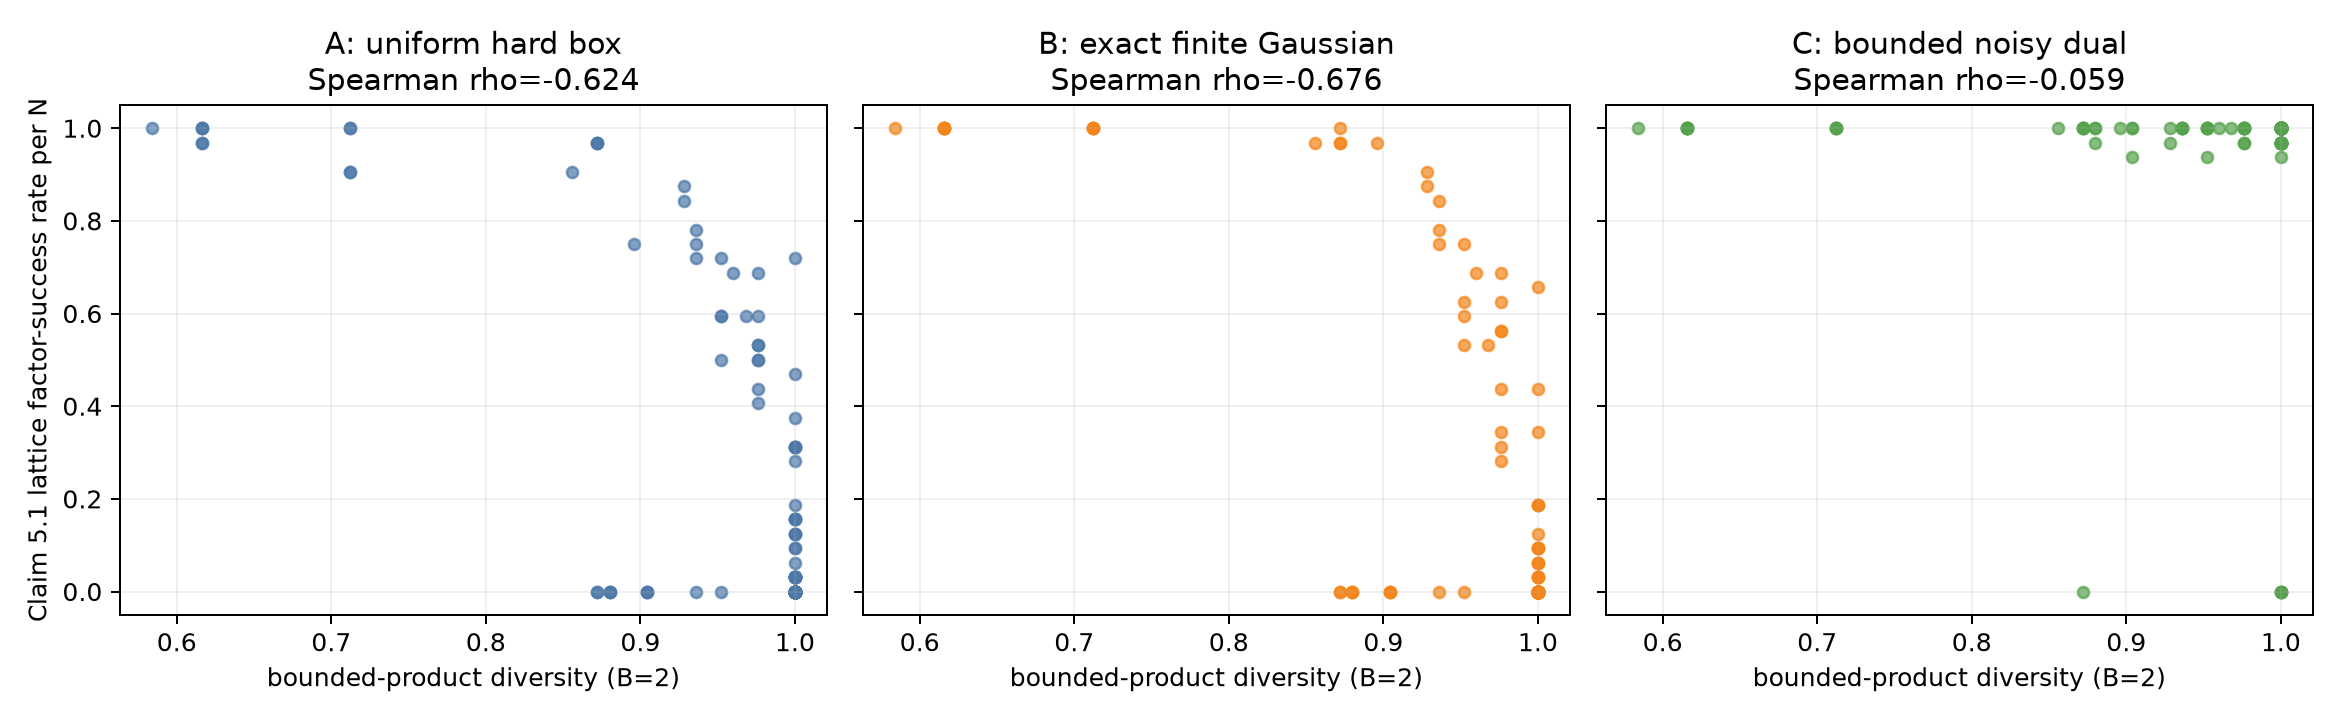

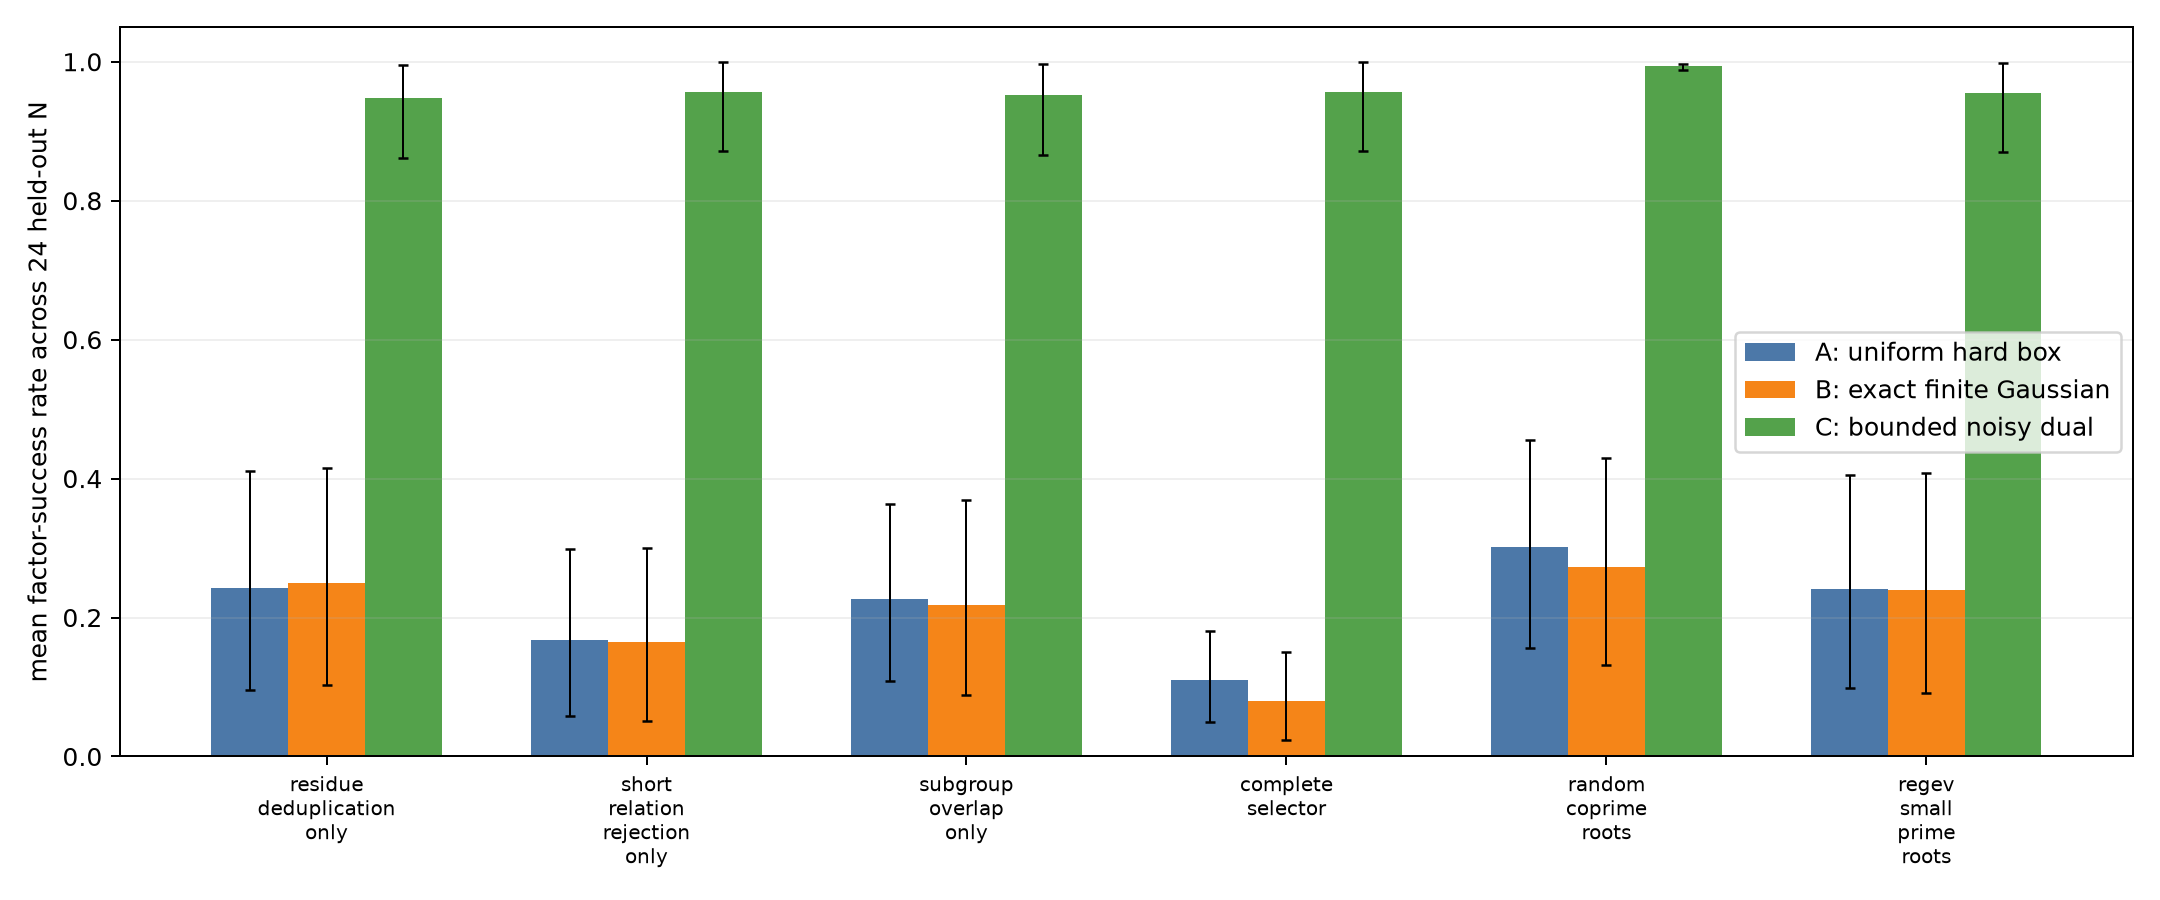

In [10]:
display(Image(filename=ROOT / 'figures/redteam_diversity_vs_lattice_success.png'))
display(Image(filename=ROOT / 'figures/redteam_model_ablation.png'))


## 9. Three final claims

1. **Verified implementation correction:** root/base provenance and the exact
   samples-to-lattice-to-factor path are implemented and tested.
2. **Verified uniform-box result:** diversity is negatively associated with
   actual LLL factor success across the 24 held-out (N)'s, but the direct
   complete-versus-small-prime contrast is not decisive.
3. **Unverified full-Regev hypothesis:** finite Gaussian B shows the same
   association, while theorem-compliant C does not. No full-Regev
   generalization is supported.

`REDTEAM_REVISION.md` contains the line-by-line proof, all 24 inputs, seeds,
selection rules, exclusions, candidate table, primary-literature audit,
limitations, and complete model-specific statistics.


## 10. Validation

The test suite covers the original notebook audit, arithmetic contracts,
root/base immutability, N=437 classification, exact hard-box and Gaussian
laws, Parseval, factor-blind HNF generation, bounded-noise model C, exact
integer lattice construction, Claim 5.1 scaling/cutoff, and factor extraction.


In [11]:
completed = subprocess.run(
    [sys.executable, '-m', 'pytest', '-q'],
    check=True, text=True, capture_output=True,
)
print(completed.stdout)


.......................................                                  [100%]
39 passed in 12.53s



In [12]:
hashes = json.loads((ROOT / 'results/redteam/artifact_hashes.json').read_text())
print('Artifact files:', len(hashes))
hashes


Artifact files: 6


{'configuration.json': '227e3b7ba3ca95299fd4e3bcf1b6e82e55fcf2f1817a48a523addf548b724259',
 'exact_models.csv': '8f909af4486f95c3116aae712f8f274686088f80efafcb8d63fa348a8ce0fcb3',
 'families.csv': 'fb649b630e8d576444d5cf06bc63c7306c6af9310322769b703900fa99a0e2f7',
 'model_statistics.json': '19e4a6a5e969f4ec83042fad42e33fbb5706e2f1c7aa7535c4d28454d064d55a',
 'n_level.csv': '1b472b89426d582acea4c6e249196f0d39741cb8c8babc5651b358260eb97a8e',
 'trials.csv': '69ccd010728b8ff11309aef5ed4d2f4c7a8afeba34c77547ccc69da4abacc4bb'}